In [32]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *
from src.experiments import *

import matplotlib.pyplot as plt
from tqdm import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Lotka-Volterra

In [33]:
lotka_volterra_rhs = generate_lotka_volterra_rhs(3, 0.1, 6, 0.1)
true_coeffs = generate_lotka_volterra_true_coefficients(3, 0.1, 6, 0.1)

x0s = [(10, 5), (5, 10), (10, 10), (5, 5), (1, 1), (2, 2), (3, 3), (7, 7)]
thresholds = np.logspace(-3, -0.5, 11).tolist()

t_span = (0, 10)

# if a parameter is a list, the experiment will be run for each combination of the parameters
# if a parameter is not a list, the same value will be used for all experiments
# the first list will be the rows and the second list will be the columns
experiment_config = {
    # define fixed parameters
    'rhs': lotka_volterra_rhs,
    'derivative_approximation': dxdt_finite_difference,
    't_eval_test': np.arange(t_span[0], t_span[1] + 0.01, 0.01),
    'np_seed': 0,
    # define parameters that can be lists
    'x0': x0s,
    'noise_level': 0.001,
    't_eval_train': None, 'dt_train': 0.01, 't_span_train': t_span,
    'threshold': thresholds,
    'poly_order': 5,
    'n_frequencies': 0,
    # define parameters that are used after the experiment
    'true_coeffs': true_coeffs
}

results = run_experiment(experiment_config)

rows are x0. there are 8 rows.
columns are threshold. there are 11 columns.
step 1 of 8


100%|██████████| 11/11 [00:04<00:00,  2.26it/s]


step 2 of 8


100%|██████████| 11/11 [00:04<00:00,  2.67it/s]


step 3 of 8


...

 45%|████▌     | 5/11 [00:02<00:03,  1.90it/s]c:\Elliot\docs\education\college\2024-2025\MS project\MS-project\src\SINDyModel.py:9: RuntimeWarning: overflow encountered in power
  return lambda x: np.prod(np.power(x, power_tuple), axis=1)
c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Elliot\docs\education\college\2024-2025\MS project\MS-project\src\SINDyModel.py:142: RuntimeWarning: invalid value encountered in matmul
  x_dot = Theta @ self.Xi
c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\scipy\integrate\_ivp\lsoda.py:161: UserWarning: lsoda: Excess accuracy requested (tolerances too small).
  solver._y, solver.t = integrator.run(
100%|██████████| 11/11 [00:06<00:00,  1.61it/s]


step 7 of 8


100%|██████████| 11/11 [00:11<00:00,  1.08s/it]


step 8 of 8


100%|██████████| 11/11 [00:04<00:00,  2.21it/s]


rows are x0. there are 8 rows.
columns are threshold. there are 11 columns.


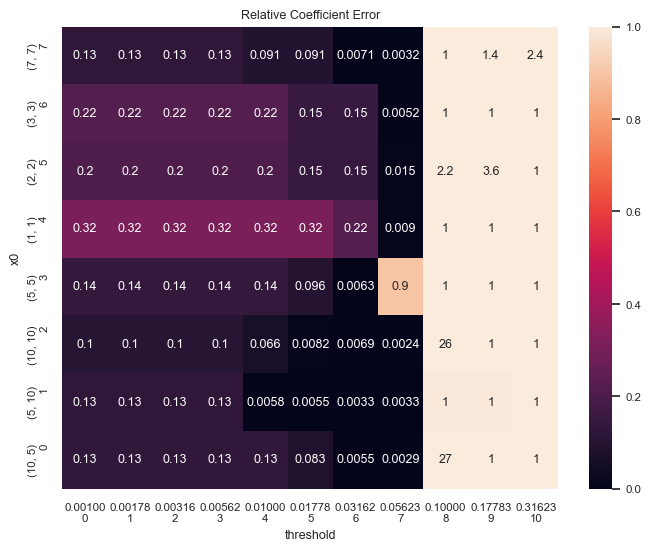

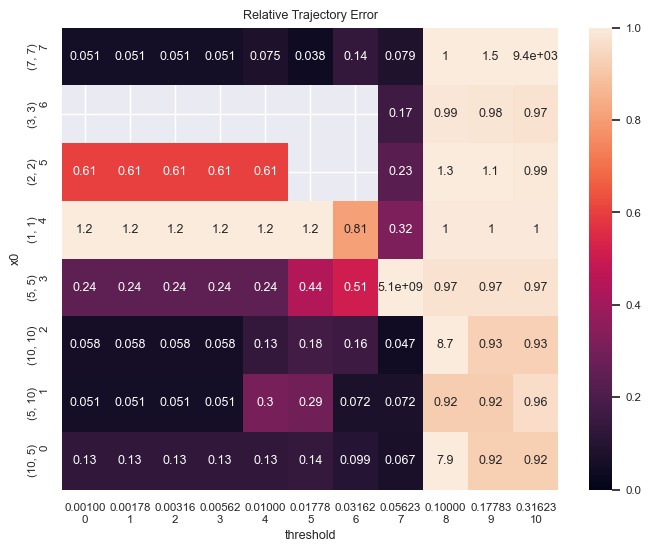

In [34]:
plot_heatmaps(experiment_config, results)

x0' = + 2.99276 x0 + -0.09976 x0 x1 
x1' = + -5.97985 x1 + 0.09968 x0 x1 


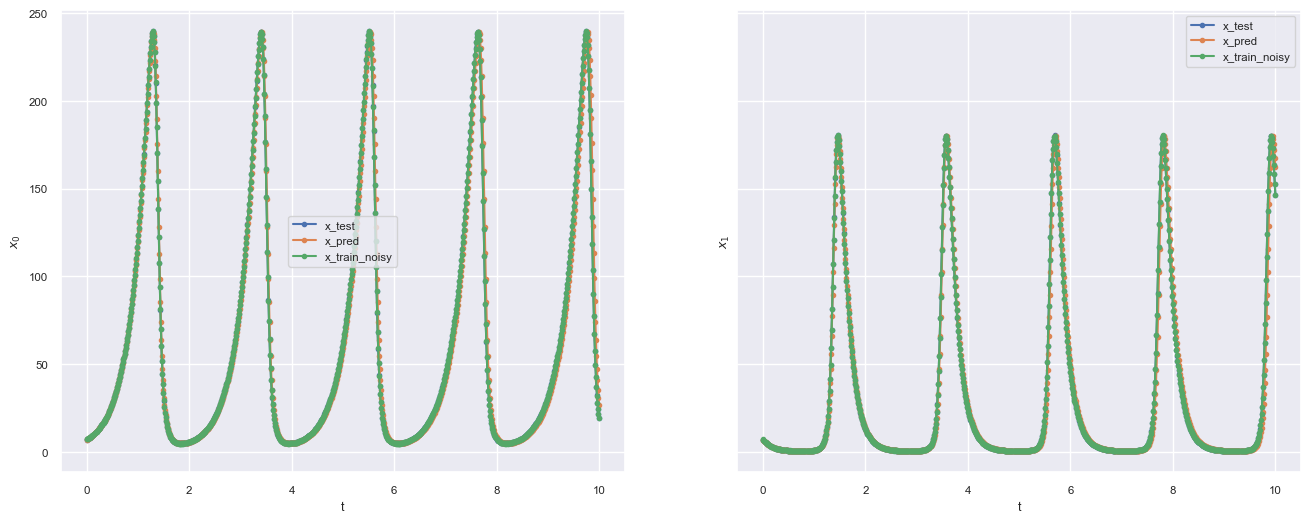

In [35]:
display_single_result(experiment_config, results, 7, 7, keys_to_display=['x_test', 'x_pred', 'x_train_noisy'])